# kNNとRandom Forestによる糖尿病データのクラス分類

`diabetes.csv` を使い、`Outcome` を目的変数としてクラス分類モデルを作成する。

このNotebookでは、kNN と Random Forest について、初期値、自動チューニング、自分で設定したハイパーパラメータの3パターンを Hold-Out 検証で比較する。


【Python セミナー 第5回】  
前回までと同じように、CSVを読み込み、説明変数と目的変数に分け、トレーニングセットとテストセットに分割してからモデルを学習する。

今回は回帰ではなく分類なので、評価指標として混同行列、Accuracy、Precision、Recall、F1、ROC 曲線、PR 曲線を使う。

## ライブラリの読み込み

このセルでは、データ処理、グラフ作成、機械学習モデル、評価指標に必要なライブラリを読み込む。乱数を固定するための `RANDOM_STATE` もここで設定する。


In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

## 評価と表示に使う関数の準備

このセルでは、モデルを学習・評価する関数と、ハイパーパラメータを表に表示しやすくするための補助関数を定義する。


In [164]:
def get_fitted_estimator(model):
    if hasattr(model, 'best_estimator_'):
        return model.best_estimator_
    return model


def format_parameter_value_for_table(value):
    if value is None:
        return 'None'
    try:
        if pd.isna(value):
            return '-'
    except (TypeError, ValueError):
        pass
    if isinstance(value, float) and value.is_integer():
        return int(value)
    return value


def get_selected_hyperparameters(model, parameter_names):
    estimator = get_fitted_estimator(model)
    params = estimator.get_params()

    selected = {}
    for parameter in parameter_names:
        if parameter in params:
            selected[parameter] = params[parameter]
            continue

        # Pipeline の場合は knn__n_neighbors のような名前で保存されるため、
        # 表示用には n_neighbors のような元の名前に戻して取り出す。
        pipeline_parameter = next(
            (name for name in params if name.endswith(f'__{parameter}')),
            None,
        )
        selected[parameter] = params.get(pipeline_parameter)

    return selected


def make_hyperparameter_settings_table(results):
    rows = []
    for result in results:
        row = {
            'model': result['model'],
            'model_family': result['model_family'],
            'setting_type': result['setting_type'],
        }
        for parameter, value in result['hyperparameters'].items():
            row[parameter] = format_parameter_value_for_table(value)
        rows.append(row)

    df = pd.DataFrame(rows)
    metadata_columns = {'model', 'model_family', 'setting_type'}
    for column in df.columns:
        if column not in metadata_columns:
            df[column] = df[column].map(format_parameter_value_for_table)
    return df


def fit_and_evaluate(
    model,
    train_features,
    test_features,
    train_targets,
    test_targets,
    model_name,
    model_family,
    setting_type,
    parameter_names,
):
    model.fit(train_features, train_targets)

    train_predictions = model.predict(train_features)
    test_predictions = model.predict(test_features)

    # predict_proba() の [:, 1] で Outcome=1 の確率を取り出す。
    test_probabilities = model.predict_proba(test_features)[:, 1]

    train_accuracy = accuracy_score(train_targets, train_predictions)
    test_accuracy = accuracy_score(test_targets, test_predictions)

    test_precision = precision_score(test_targets, test_predictions, zero_division=0)
    test_recall = recall_score(test_targets, test_predictions, zero_division=0)
    test_f1 = f1_score(test_targets, test_predictions, zero_division=0)
    test_roc_auc = roc_auc_score(test_targets, test_probabilities)
    test_pr_auc = average_precision_score(test_targets, test_probabilities)

    tn, fp, fn, tp = confusion_matrix(
        test_targets, test_predictions, labels=[0, 1]
    ).ravel()

    # RandomizedSearchCV など SearchCV 系の場合は交差検証で選ばれた最良スコアとパラメータを保存する。
    # cv_best_score は RandomizedSearchCV に指定した scoring に基づく CV 内の最良スコア。
    if hasattr(model, 'best_score_'):
        cv_best_score = model.best_score_
        best_params = model.best_params_
    else:
        cv_best_score = None
        best_params = None

    hyperparameters = get_selected_hyperparameters(model, parameter_names)

    print(f'\n{model_name}')
    print(f'Pattern:           {setting_type}')
    print('Hyperparameters:')
    for parameter, value in hyperparameters.items():
        print(f'  {parameter}: {value}')
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy:     {test_accuracy:.4f}')
    print(f'Test Precision:    {test_precision:.4f}')
    print(f'Test Recall:       {test_recall:.4f}')
    print(f'Test F1:           {test_f1:.4f}')
    print(f'Test ROC AUC:      {test_roc_auc:.4f}')
    print(f'Test PR AUC:       {test_pr_auc:.4f}')
    print(f'Confusion Matrix:  TN={tn}, FP={fp}, FN={fn}, TP={tp}')

    row = {
        'model': model_name,
        'model_family': model_family,
        'setting_type': setting_type,
        'test_tn': tn,
        'test_fp': fp,
        'test_fn': fn,
        'test_tp': tp,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc,
        'cv_best_score': cv_best_score,
        'best_params': best_params,
        'hyperparameters': hyperparameters,
    }
    for parameter, value in hyperparameters.items():
        row[f'param_{parameter}'] = format_parameter_value_for_table(value)

    return row, model


## CSVファイルの読み込み

このセルでは、`diabetes.csv` を pandas の DataFrame として読み込み、データの中身を表示して確認する。


In [165]:
# CSV ファイルを読み込む。
# CSV はカンマ区切りの表形式データ。
# pd.read_csv() を使うと、CSVを pandas の DataFrame として読み込める。
df = pd.read_csv('diabetes.csv')

# Jupyter Notebook では、セルの最後に変数名を書くと中身が表示される。
# ここでは読み込んだ表 df を確認している。
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## データの基本情報の確認

このセルでは、データ数、列数、欠損値、目的変数 `Outcome` のクラス数と割合、各特徴量の基本統計量を確認する。


In [166]:
# データの行数・列数を確認する。
print(f'データ数: {df.shape[0]}')
print(f'列数: {df.shape[1]}')

# 欠損値があると、そのままでは多くの scikit-learn モデルで学習できない。
# 今回のCSVに欠損値が含まれていないか確認する。
print('\n欠損値の数:')
print(df.isna().sum())

# Outcome は今回の目的変数。
# 0 と 1 の件数に大きな偏りがないかを確認する。
print('\nOutcome の件数:')
print(df['Outcome'].value_counts().sort_index())

print('\nOutcome の割合:')
print(df['Outcome'].value_counts(normalize=True).sort_index())

# 数値データの平均、標準偏差、最小値、最大値などを確認する。
df.describe()

データ数: 768
列数: 9

欠損値の数:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome の件数:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome の割合:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 前処理と説明変数・目的変数の作成

このセルでは、医学的にあり得ない 0 を欠損値として扱い、中央値で補完する。その後、目的変数 `y` と説明変数 `x` に分ける。


In [167]:
drop_list = []
df_clean = df.drop(columns=drop_list)

# このデータセットでは Glucose, BloodPressure, SkinThickness, BMI の値が
# 0 になっているサンプルが存在するが、これらは医学的にあり得ない値であり、
# 測定失敗・未記録による欠損値とみなして NaN に置換してから補完する。
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
df_clean[zero_invalid_cols] = df_clean[zero_invalid_cols].replace(0, np.nan)

print('0 を欠損値として扱った後の欠損値の数:')
print(df_clean[zero_invalid_cols].isna().sum())

target = 'Outcome'
if target not in df_clean.columns:
    raise ValueError(f'{target} 列が見つかりません。')

y = df_clean[target].astype(int)
x = df_clean.drop(columns=[target])
x = x.select_dtypes(include='number').copy()

# 欠損値を各列の中央値で補完する。
# 中央値は外れ値の影響を受けにくく、欠損値補完に適している。
x = x.fillna(x.median())

print(f'\n目的変数: {target}')
print(f'説明変数: {list(x.columns)}')
x

0 を欠損値として扱った後の欠損値の数:
Glucose            5
BloodPressure     35
SkinThickness    227
BMI               11
dtype: int64

目的変数: Outcome
説明変数: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,0,33.6,0.627,50
1,1,85.0,66.0,29.0,0,26.6,0.351,31
2,8,183.0,64.0,29.0,0,23.3,0.672,32
3,1,89.0,66.0,23.0,94,28.1,0.167,21
4,0,137.0,40.0,35.0,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180,32.9,0.171,63
764,2,122.0,70.0,27.0,0,36.8,0.340,27
765,5,121.0,72.0,23.0,112,26.2,0.245,30
766,1,126.0,60.0,29.0,0,30.1,0.349,47


## トレーニングセットとテストセットへの分割

このセルでは、データをトレーニング用とテスト用に分割し、`StandardScaler` で標準化する。標準化はトレーニングデータで学習し、テストデータには変換だけを行う。


In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    shuffle=True,
    random_state=RANDOM_STATE,
    stratify=y,
)

# StandardScaler を使ってオートスケーリングする。
# fit_transform() はトレーニングデータの平均・標準偏差を学習しながら変換する。
# transform() はトレーニングデータで学習した統計量を使ってテストデータを変換する。
# テストデータには transform() のみ使うことで、データリークを防ぐ。
scaler = StandardScaler()
auto_X_train = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
auto_X_test = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print(f'目的変数: {target}, 説明変数: {x.shape[1]}, データ数: {x.shape[0]}')
print(f'トレーニングセット: {X_train.shape[0]}, テストセット: {X_test.shape[0]}')

print('\nトレーニングセットのクラス割合:')
print(y_train.value_counts(normalize=True).sort_index())

print('\nテストセットのクラス割合:')
print(y_test.value_counts(normalize=True).sort_index())

目的変数: Outcome, 説明変数: 8, データ数: 768
トレーニングセット: 614, テストセット: 154

トレーニングセットのクラス割合:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

テストセットのクラス割合:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## kNNのマニュアル設定

このセルでは、kNN のマニュアル設定値を指定する。値を変更したら、このセルから下を再実行すると比較結果に反映される。


In [ ]:
# ===== kNN のマニュアル設定 =====
# 値を変更したら、このセルから下を再実行してください。

# n_neighbors: 近くの何個のデータを見るか。小さいほど細かく反応し、大きいほどなめらかになる。
# weights: 'uniform' は全て同じ重み、'distance' は近いデータを重く見る。
# p: 1 はマンハッタン距離、2 はユークリッド距離。
KNN_MANUAL_PARAMS = {
    'n_neighbors': 5,
    'weights': 'distance',
    'p': 2,
}

# 結果表に表示する kNN のハイパーパラメータ
KNN_REPORT_PARAMETERS = ['n_neighbors', 'weights', 'p']


## Random Forestのマニュアル設定

このセルでは、Random Forest のマニュアル設定値を指定する。値を変更したら、このセルから下を再実行すると比較結果に反映される。


In [170]:
# ===== Random Forest のマニュアル設定 =====
# 値を変更したら、このセルから下を再実行してください。

# n_estimators: 作る木の本数。大きいほど安定しやすいが、計算時間は増える。
# max_depth: 木の最大深さ。None は制限なし。
# min_samples_split: ノードをさらに分割するために必要な最小サンプル数。
# min_samples_leaf: 葉に必要な最小サンプル数。大きいほど過学習を抑えやすい。
# max_features: 各分岐で使う特徴量数。'sqrt', 'log2', None, 0.5 などを指定できる。
# criterion: 分割の良さを評価する基準。'gini', 'entropy', 'log_loss' などを指定できる。
# bootstrap: ブートストラップ標本を使うかどうか。
# class_weight: クラス不均衡への重み付け。None, 'balanced', 'balanced_subsample' などを指定できる。
RF_MANUAL_PARAMS = {
    'n_estimators': 1000,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'criterion': 'gini',
    'bootstrap': True,
    'class_weight': None,
}

# 結果表に表示する Random Forest のハイパーパラメータ
RF_REPORT_PARAMETERS = [
    'n_estimators',
    'max_depth',
    'min_samples_split',
    'min_samples_leaf',
    'max_features',
    'criterion',
    'bootstrap',
    'class_weight',
]


## 初期値とマニュアル設定のモデルを学習・評価

このセクションでは、kNN と Random Forest について、初期値のモデルと自分で設定したモデルを学習し、Hold-Out テストセットで評価する。


In [171]:
results = []
trained_models = {}
model_test_features = {}

metric_display_columns = [
    'test_tn',
    'test_fp',
    'test_fn',
    'test_tp',
    'train_accuracy',
    'test_accuracy',
    'test_precision',
    'test_recall',
    'test_f1',
    'test_roc_auc',
    'test_pr_auc',
    'cv_best_score',
]
parameter_display_columns = [
    'param_n_neighbors',
    'param_weights',
    'param_p',
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'param_max_features',
    'param_criterion',
    'param_bootstrap',
    'param_class_weight',
]
summary_display_columns = [
    'model',
    'model_family',
    'setting_type',
    *parameter_display_columns,
    *metric_display_columns,
]


### kNNの初期値・マニュアル設定モデル

このセルでは、kNN の初期値モデルとマニュアル設定モデルを学習・評価する。


In [172]:
knn_default = KNeighborsClassifier()
row, trained_model = fit_and_evaluate(
    knn_default,
    auto_X_train,
    auto_X_test,
    y_train,
    y_test,
    'kNN (default)',
    'kNN',
    '初期値',
    KNN_REPORT_PARAMETERS,
)
results.append(row)
trained_models[row['model']] = trained_model
model_test_features[row['model']] = auto_X_test

knn_manual = KNeighborsClassifier(**KNN_MANUAL_PARAMS)
row, trained_model = fit_and_evaluate(
    knn_manual,
    auto_X_train,
    auto_X_test,
    y_train,
    y_test,
    'kNN (manual)',
    'kNN',
    '自分で設定',
    KNN_REPORT_PARAMETERS,
)
results.append(row)
trained_models[row['model']] = trained_model
model_test_features[row['model']] = auto_X_test

default_manual_results_df = pd.DataFrame(results)
default_manual_display_df = default_manual_results_df.reindex(columns=summary_display_columns)
for column in parameter_display_columns:
    default_manual_display_df[column] = default_manual_display_df[column].map(
        format_parameter_value_for_table
    )
default_manual_display_df



kNN (default)
Pattern:           初期値
Hyperparameters:
  n_neighbors: 5
  weights: uniform
  p: 2
Training Accuracy: 0.8257
Test Accuracy:     0.7468
Test Precision:    0.6667
Test Recall:       0.5556
Test F1:           0.6061
Test ROC AUC:      0.7870
Test PR AUC:       0.6195
Confusion Matrix:  TN=85, FP=15, FN=24, TP=30

kNN (manual)
Pattern:           自分で設定
Hyperparameters:
  n_neighbors: 7
  weights: distance
  p: 2
Training Accuracy: 1.0000
Test Accuracy:     0.7273
Test Precision:    0.6304
Test Recall:       0.5370
Test F1:           0.5800
Test ROC AUC:      0.7870
Test PR AUC:       0.6545
Confusion Matrix:  TN=83, FP=17, FN=25, TP=29


,model,model_family,setting_type,param_n_neighbors,param_weights,param_p,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,...,test_fn,test_tp,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,cv_best_score
0,kNN (default),kNN,初期値,5,uniform,2,-,-,-,-,...,24,30,0.825733,0.746753,0.666667,0.555556,0.606061,0.787037,0.619490,None
1,kNN (manual),kNN,自分で設定,7,distance,2,-,-,-,-,...,25,29,1.000000,0.727273,0.630435,0.537037,0.580000,0.787037,0.654545,None


### Random Forestの初期値・マニュアル設定モデル

このセルでは、Random Forest の初期値モデルとマニュアル設定モデルを学習・評価する。


In [173]:
# Random Forest は決定木ベースなのでスケールの影響を受けにくいが、
# 参照書に倣い kNN と同じ標準化済みデータで統一する。
# oob_score=True で Out-of-Bag スコアを計算する。
# OOB スコアはバギングで使われなかったサンプルへの予測精度で、
# テストデータを使わずにモデルの汎化性能をおおまかに推定できる。
rf_default = RandomForestClassifier(random_state=RANDOM_STATE, oob_score=True)
row, trained_model = fit_and_evaluate(
    rf_default,
    auto_X_train,
    auto_X_test,
    y_train,
    y_test,
    'Random Forest (default)',
    'Random Forest',
    '初期値',
    RF_REPORT_PARAMETERS,
)
results.append(row)
trained_models[row['model']] = trained_model
model_test_features[row['model']] = auto_X_test

rf_manual = RandomForestClassifier(
    **{'random_state': RANDOM_STATE, 'oob_score': True, **RF_MANUAL_PARAMS}
)
row, trained_model = fit_and_evaluate(
    rf_manual,
    auto_X_train,
    auto_X_test,
    y_train,
    y_test,
    'Random Forest (manual)',
    'Random Forest',
    '自分で設定',
    RF_REPORT_PARAMETERS,
)
results.append(row)
trained_models[row['model']] = trained_model
model_test_features[row['model']] = auto_X_test

print()
print(f'Random Forest (default) OOB Score: {rf_default.oob_score_:.4f}')
print(f'Random Forest (manual) OOB Score: {rf_manual.oob_score_:.4f}')

default_manual_results_df = pd.DataFrame(results)
default_manual_display_df = default_manual_results_df.reindex(columns=summary_display_columns)
for column in parameter_display_columns:
    default_manual_display_df[column] = default_manual_display_df[column].map(
        format_parameter_value_for_table
    )
default_manual_display_df



Random Forest (default)
Pattern:           初期値
Hyperparameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  criterion: gini
  bootstrap: True
  class_weight: None
Training Accuracy: 1.0000
Test Accuracy:     0.7857
Test Precision:    0.7234
Test Recall:       0.6296
Test F1:           0.6733
Test ROC AUC:      0.8349
Test PR AUC:       0.7357
Confusion Matrix:  TN=87, FP=13, FN=20, TP=34

Random Forest (manual)
Pattern:           自分で設定
Hyperparameters:
  n_estimators: 1000
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: sqrt
  criterion: gini
  bootstrap: True
  class_weight: None
Training Accuracy: 0.9805
Test Accuracy:     0.7532
Test Precision:    0.6667
Test Recall:       0.5926
Test F1:           0.6275
Test ROC AUC:      0.8176
Test PR AUC:       0.7064
Confusion Matrix:  TN=84, FP=16, FN=22, TP=32

Random Forest (default) OOB Score: 0.7524
Random Forest (manual) OOB Score: 0.7655


,model,model_family,setting_type,param_n_neighbors,param_weights,param_p,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,...,test_fn,test_tp,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,cv_best_score
0,kNN (default),kNN,初期値,5,uniform,2,-,-,-,-,...,24,30,0.825733,0.746753,0.666667,0.555556,0.606061,0.787037,0.619490,None
1,kNN (manual),kNN,自分で設定,7,distance,2,-,-,-,-,...,25,29,1.000000,0.727273,0.630435,0.537037,0.580000,0.787037,0.654545,None
2,Random Forest (default),Random Forest,初期値,-,-,-,100,None,2,1,...,20,34,1.000000,0.785714,0.723404,0.629630,0.673267,0.834907,0.735667,None
3,Random Forest (manual),Random Forest,自分で設定,-,-,-,1000,None,2,2,...,22,32,0.980456,0.753247,0.666667,0.592593,0.627451,0.817593,0.706353,None


## 自動チューニングの実行

このセクションでは、`RandomizedSearchCV` を使って kNN と Random Forest のハイパーパラメータを自動探索し、選ばれたパラメータで学習・評価する。

`RandomizedSearchCV` はすべての組み合わせを試すのではなく、候補の中からランダムに `n_iter` 回だけ試すため、広めの候補を効率よく探索できる。


In [174]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


### kNNの自動チューニング

このセルでは、`Pipeline` で標準化と kNN をまとめ、`RandomizedSearchCV` で kNN のハイパーパラメータを探索する。

`Pipeline` を使うと、交差検証の各分割内で標準化が学習されるため、検証データの情報が標準化に混ざることを防げる。


In [175]:
# ==================================================
# 1. 標準化とkNNをPipelineでまとめる
# ==================================================
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()),
])


# ==================================================
# 2. ハイパーパラメータの探索範囲
# ==================================================
# randint(1, 31) は 1 以上 30 以下の整数をランダムに選ぶ。
KNN_PARAM_DISTRIBUTIONS = {
    'knn__n_neighbors': randint(1, 31),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
}


# ==================================================
# 3. RandomizedSearchCVの設定
# ==================================================
knn_random_search = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=KNN_PARAM_DISTRIBUTIONS,
    n_iter=30,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE,
    return_train_score=True,
    verbose=1,
)


# ==================================================
# 4. 学習データだけを使って最適化し、Hold-Outテストセットで評価
# ==================================================
# Pipeline の中で標準化するため、ここでは標準化前の X_train / X_test を渡す。
row, trained_model = fit_and_evaluate(
    knn_random_search,
    X_train,
    X_test,
    y_train,
    y_test,
    'kNN (auto tuned)',
    'kNN',
    '自動チューニング',
    KNN_REPORT_PARAMETERS,
)
results.append(row)
trained_models[row['model']] = trained_model
model_test_features[row['model']] = X_test

# 後続セルでも以前の変数名で参照できるようにしておく。
knn_tuned = knn_random_search


# ==================================================
# 5. 最適なハイパーパラメータを取得
# ==================================================
KNN_BEST_PARAMS = {
    'n_neighbors': knn_random_search.best_params_['knn__n_neighbors'],
    'weights': knn_random_search.best_params_['knn__weights'],
    'p': knn_random_search.best_params_['knn__p'],
}


# ==================================================
# 6. 最適化結果を表示
# ==================================================
print('最適なハイパーパラメータ')
print(KNN_BEST_PARAMS)
print('交差検証における最良スコア:', knn_random_search.best_score_)
print(f'試行回数: {knn_random_search.n_iter}')


# ==================================================
# 7. 最適化済みモデルを取得し、テストデータを予測
# ==================================================
# StandardScaler と kNN の両方を含む Pipeline。
knn_best_model = knn_random_search.best_estimator_
y_pred_knn = knn_best_model.predict(X_test)
y_pred_proba_knn = knn_best_model.predict_proba(X_test)

# 現時点で実際に使われた kNN のハイパーパラメータを確認する。
hyperparameter_settings_df = make_hyperparameter_settings_table(results)
hyperparameter_settings_df[hyperparameter_settings_df['model_family'] == 'kNN']


Fitting 5 folds for each of 30 candidates, totalling 150 fits

kNN (auto tuned)
Pattern:           自動チューニング
Hyperparameters:
  n_neighbors: 15
  weights: uniform
  p: 2
Training Accuracy: 0.7997
Test Accuracy:     0.7597
Test Precision:    0.6977
Test Recall:       0.5556
Test F1:           0.6186
Test ROC AUC:      0.8073
Test PR AUC:       0.6828
Confusion Matrix:  TN=87, FP=13, FN=24, TP=30
最適なハイパーパラメータ
{'n_neighbors': 15, 'weights': 'uniform', 'p': 2}
交差検証における最良スコア: 0.723564463742427
試行回数: 30


,model,model_family,setting_type,n_neighbors,weights,p,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,criterion,bootstrap,class_weight
0,kNN (default),kNN,初期値,5,uniform,2,-,-,-,-,-,-,-,-
1,kNN (manual),kNN,自分で設定,7,distance,2,-,-,-,-,-,-,-,-
4,kNN (auto tuned),kNN,自動チューニング,15,uniform,2,-,-,-,-,-,-,-,-


### Random Forestの自動チューニング

このセルでは、`RandomizedSearchCV` で Random Forest のハイパーパラメータを探索する。

`min_samples_split`, `criterion`, `bootstrap`, `class_weight` も探索範囲に含め、交差検証の `f1_macro` が高くなる設定を選ぶ。


In [176]:
# ==================================================
# 1. Random Forestモデル
# ==================================================
# bootstrap=False も探索するため、自動チューニングでは oob_score=True を指定しない。
rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


# ==================================================
# 2. 探索範囲
# ==================================================
RF_PARAM_DISTRIBUTIONS = {
    # 決定木の本数: 100以上1000以下
    'n_estimators': randint(100, 1001),

    # 決定木の最大深さ
    'max_depth': [
        None,
        5,
        10,
        15,
        20,
        30,
        40,
    ],

    # ノードを分割するために必要な最小データ数
    'min_samples_split': randint(2, 21),

    # 1つの葉に必要な最小データ数
    'min_samples_leaf': randint(1, 11),

    # 分割時に調べる特徴量数
    'max_features': [
        'sqrt',
        'log2',
        None,
        0.5,
    ],

    # 分割の評価基準
    'criterion': [
        'gini',
        'entropy',
        'log_loss',
    ],

    # ブートストラップ標本を使うか
    'bootstrap': [
        True,
        False,
    ],

    # クラス不均衡への対応
    'class_weight': [
        None,
        'balanced',
        'balanced_subsample',
    ],
}


# ==================================================
# 3. RandomizedSearchCV
# ==================================================
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=RF_PARAM_DISTRIBUTIONS,
    n_iter=100,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
    verbose=1,
)


# ==================================================
# 4. 学習データで最適化し、Hold-Outテストセットで評価
# ==================================================
row, trained_model = fit_and_evaluate(
    rf_random_search,
    X_train,
    X_test,
    y_train,
    y_test,
    'Random Forest (auto tuned)',
    'Random Forest',
    '自動チューニング',
    RF_REPORT_PARAMETERS,
)
results.append(row)
trained_models[row['model']] = trained_model
model_test_features[row['model']] = X_test

# 後続セルでも以前の変数名で参照できるようにしておく。
rf_tuned = rf_random_search


# ==================================================
# 5. 最適な設定
# ==================================================
RF_BEST_PARAMS = rf_random_search.best_params_

print('最適なハイパーパラメータ')
print(RF_BEST_PARAMS)
print('交差検証の最良Macro F1:', rf_random_search.best_score_)
print(f'試行回数: {rf_random_search.n_iter}')


# ==================================================
# 6. 最適化されたモデル
# ==================================================
rf_best_model = rf_random_search.best_estimator_


# ==================================================
# 7. テストデータを予測
# ==================================================
y_pred_rf = rf_best_model.predict(X_test)


# ==================================================
# 8. テストデータで最終評価
# ==================================================
accuracy = accuracy_score(y_test, y_pred_rf)
macro_f1 = f1_score(y_test, y_pred_rf, average='macro')
conf_matrix = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf, zero_division=0)

print()
print('テストデータのAccuracy')
print(accuracy)

print()
print('テストデータのMacro F1')
print(macro_f1)

print()
print('混同行列')
print(conf_matrix)

print()
print('分類レポート')
print(report)

# 各パターンで実際に使われたハイパーパラメータを一覧で確認する。
hyperparameter_settings_df = make_hyperparameter_settings_table(results)
hyperparameter_settings_df


Fitting 5 folds for each of 100 candidates, totalling 500 fits

Random Forest (auto tuned)
Pattern:           自動チューニング
Hyperparameters:
  n_estimators: 355
  max_depth: 20
  min_samples_split: 2
  min_samples_leaf: 7
  max_features: 0.5
  criterion: gini
  bootstrap: True
  class_weight: balanced_subsample
Training Accuracy: 0.8681
Test Accuracy:     0.7468
Test Precision:    0.6190
Test Recall:       0.7222
Test F1:           0.6667
Test ROC AUC:      0.8317
Test PR AUC:       0.7244
Confusion Matrix:  TN=76, FP=24, FN=15, TP=39
最適なハイパーパラメータ
{'bootstrap': True, 'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 355}
交差検証の最良Macro F1: 0.7590364205249462
試行回数: 100

テストデータのAccuracy
0.7467532467532467

テストデータのMacro F1
0.7312390924956369

混同行列
[[76 24]
 [15 39]]

分類レポート
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
      

,model,model_family,setting_type,n_neighbors,weights,p,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,criterion,bootstrap,class_weight
0,kNN (default),kNN,初期値,5,uniform,2,-,-,-,-,-,-,-,-
1,kNN (manual),kNN,自分で設定,7,distance,2,-,-,-,-,-,-,-,-
2,Random Forest (default),Random Forest,初期値,-,-,-,100,None,2,1,sqrt,gini,True,None
3,Random Forest (manual),Random Forest,自分で設定,-,-,-,1000,None,2,2,sqrt,gini,True,None
4,kNN (auto tuned),kNN,自動チューニング,15,uniform,2,-,-,-,-,-,-,-,-
5,Random Forest (auto tuned),Random Forest,自動チューニング,-,-,-,355,20,2,7,0.5,gini,True,balanced_subsample


## kNNのハイパーパラメータ比較

このセルでは、kNN の初期値、マニュアル、オートで使われたハイパーパラメータを横並びの表にする。後続の Random Forest 表でも使う比較表作成関数もここで定義する。


In [177]:
# kNN の初期値・マニュアル・オートを横並びで比較する。
def make_model_hyperparameter_comparison_table(model_family, parameters):
    setting_order = ['初期値', '自分で設定', '自動チューニング']
    setting_labels = {
        '初期値': '初期値',
        '自分で設定': 'マニュアル',
        '自動チューニング': 'オート',
    }

    family_settings = hyperparameter_settings_df[
        hyperparameter_settings_df['model_family'] == model_family
    ].set_index('setting_type')

    rows = []
    for parameter in parameters:
        values = {}
        for setting in setting_order:
            column_name = setting_labels[setting]
            if setting in family_settings.index and parameter in family_settings.columns:
                values[column_name] = format_parameter_value_for_table(
                    family_settings.loc[setting, parameter]
                )
            else:
                values[column_name] = '-'

        rows.append(
            {
                'parameter': parameter,
                '初期値': values['初期値'],
                'マニュアル': values['マニュアル'],
                'オート': values['オート'],
                'マニュアルで初期値から変更': (
                    '変更あり' if values['マニュアル'] != values['初期値'] else '同じ'
                ),
                'オートで初期値から変更': (
                    '変更あり' if values['オート'] != values['初期値'] else '同じ'
                ),
            }
        )

    return pd.DataFrame(rows)

knn_hyperparameter_comparison_df = make_model_hyperparameter_comparison_table(
    'kNN',
    KNN_REPORT_PARAMETERS,
)
knn_hyperparameter_comparison_df


,parameter,初期値,マニュアル,オート,マニュアルで初期値から変更,オートで初期値から変更
0,n_neighbors,5,7,15,変更あり,変更あり
1,weights,uniform,distance,uniform,変更あり,同じ
2,p,2,2,2,同じ,同じ


## Random Forestのハイパーパラメータ比較

このセルでは、Random Forest の初期値、マニュアル、オートで使われたハイパーパラメータを横並びの表にする。


In [178]:
# Random Forest の初期値・マニュアル・オートを横並びで比較する。
rf_hyperparameter_comparison_df = make_model_hyperparameter_comparison_table(
    'Random Forest',
    RF_REPORT_PARAMETERS,
)

# 必要に応じて、2つの表をまとめたデータも使えるようにしておく。
hyperparameter_value_comparison_df = pd.concat(
    [
        knn_hyperparameter_comparison_df.assign(model_family='kNN'),
        rf_hyperparameter_comparison_df.assign(model_family='Random Forest'),
    ],
    ignore_index=True,
)

rf_hyperparameter_comparison_df


,parameter,初期値,マニュアル,オート,マニュアルで初期値から変更,オートで初期値から変更
0,n_estimators,100,1000,355,変更あり,変更あり
1,max_depth,None,None,20,同じ,変更あり
2,min_samples_split,2,2,2,同じ,同じ
3,min_samples_leaf,1,2,7,変更あり,変更あり
4,max_features,sqrt,sqrt,0.5,同じ,変更あり
5,criterion,gini,gini,gini,同じ,同じ
6,bootstrap,True,True,True,同じ,同じ
7,class_weight,None,None,balanced_subsample,同じ,変更あり


## 評価結果の一覧表を作成

このセルでは、すべてのモデルの評価指標と実際に使われたハイパーパラメータを1つの表にまとめ、ROC AUC が高い順に表示する。


In [179]:
comparison_df = pd.DataFrame(results)
comparison_columns = [
    'model',
    'model_family',
    'setting_type',
    *parameter_display_columns,
    'test_tn',
    'test_fp',
    'test_fn',
    'test_tp',
    'train_accuracy',
    'test_accuracy',
    'test_precision',
    'test_recall',
    'test_f1',
    'test_roc_auc',
    'test_pr_auc',
    'cv_best_score',
    'best_params',
    'hyperparameters',
]

comparison_df = comparison_df.reindex(columns=comparison_columns)
for column in parameter_display_columns:
    comparison_df[column] = comparison_df[column].map(format_parameter_value_for_table)
comparison_df.sort_values(by='test_roc_auc', ascending=False)


,model,model_family,setting_type,param_n_neighbors,param_weights,param_p,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,...,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,cv_best_score,best_params,hyperparameters
2,Random Forest (default),Random Forest,初期値,-,-,-,100,None,2,1,...,1.000000,0.785714,0.723404,0.629630,0.673267,0.834907,0.735667,NaN,None,"{'n_estimators': 100, 'max_depth': None, 'min_..."
5,Random Forest (auto tuned),Random Forest,自動チューニング,-,-,-,355,20,2,7,...,0.868078,0.746753,0.619048,0.722222,0.666667,0.831667,0.724369,0.759036,"{'bootstrap': True, 'class_weight': 'balanced_...","{'n_estimators': 355, 'max_depth': 20, 'min_sa..."
3,Random Forest (manual),Random Forest,自分で設定,-,-,-,1000,None,2,2,...,0.980456,0.753247,0.666667,0.592593,0.627451,0.817593,0.706353,NaN,None,"{'n_estimators': 1000, 'max_depth': None, 'min..."
4,kNN (auto tuned),kNN,自動チューニング,15,uniform,2,-,-,-,-,...,0.799674,0.759740,0.697674,0.555556,0.618557,0.807315,0.682845,0.723564,"{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__we...","{'n_neighbors': 15, 'weights': 'uniform', 'p': 2}"
1,kNN (manual),kNN,自分で設定,7,distance,2,-,-,-,-,...,1.000000,0.727273,0.630435,0.537037,0.580000,0.787037,0.654545,NaN,None,"{'n_neighbors': 7, 'weights': 'distance', 'p': 2}"
0,kNN (default),kNN,初期値,5,uniform,2,-,-,-,-,...,0.825733,0.746753,0.666667,0.555556,0.606061,0.787037,0.619490,NaN,None,"{'n_neighbors': 5, 'weights': 'uniform', 'p': 2}"


## 評価指標の数値比較

このセルでは、kNN の初期値、マニュアル、オート、Random Forest の初期値、マニュアル、オートの順に、各評価指標を横並びの表で比較する。


In [180]:
# 指定した順番で、各モデルの評価指標を横方向に並べて比較する。
metric_row_order = [
    ('kNN', '初期値', 'kNN (default)'),
    ('kNN', 'マニュアル', 'kNN (manual)'),
    ('kNN', 'オート', 'kNN (auto tuned)'),
    ('Random Forest', '初期値', 'Random Forest (default)'),
    ('Random Forest', 'マニュアル', 'Random Forest (manual)'),
    ('Random Forest', 'オート', 'Random Forest (auto tuned)'),
]

metric_columns_for_comparison = [
    'train_accuracy',
    'test_accuracy',
    'test_precision',
    'test_recall',
    'test_f1',
    'test_roc_auc',
    'test_pr_auc',
    'test_tn',
    'test_fp',
    'test_fn',
    'test_tp',
]

metric_column_labels = {
    'train_accuracy': 'Training Accuracy',
    'test_accuracy': 'Test Accuracy',
    'test_precision': 'Precision',
    'test_recall': 'Recall',
    'test_f1': 'F1',
    'test_roc_auc': 'ROC AUC',
    'test_pr_auc': 'PR AUC',
    'test_tn': 'TN',
    'test_fp': 'FP',
    'test_fn': 'FN',
    'test_tp': 'TP',
}

comparison_by_model = comparison_df.set_index('model')
metric_comparison_rows = []

for model_family, setting_type, model_name in metric_row_order:
    row = comparison_by_model.loc[model_name]
    metric_row = {
        'モデル': model_family,
        '設定': setting_type,
    }
    for column in metric_columns_for_comparison:
        value = row[column]
        if column.startswith('test_t') and column in ['test_tn', 'test_tp']:
            metric_row[metric_column_labels[column]] = int(value)
        elif column in ['test_fp', 'test_fn']:
            metric_row[metric_column_labels[column]] = int(value)
        else:
            metric_row[metric_column_labels[column]] = round(value, 4)
    metric_comparison_rows.append(metric_row)

metric_comparison_df = pd.DataFrame(metric_comparison_rows)
metric_comparison_df


,モデル,設定,Training Accuracy,Test Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,TN,FP,FN,TP
0,kNN,初期値,0.8257,0.7468,0.6667,0.5556,0.6061,0.7870,0.6195,85,15,24,30
1,kNN,マニュアル,1.0000,0.7273,0.6304,0.5370,0.5800,0.7870,0.6545,83,17,25,29
2,kNN,オート,0.7997,0.7597,0.6977,0.5556,0.6186,0.8073,0.6828,87,13,24,30
3,Random Forest,初期値,1.0000,0.7857,0.7234,0.6296,0.6733,0.8349,0.7357,87,13,20,34
4,Random Forest,マニュアル,0.9805,0.7532,0.6667,0.5926,0.6275,0.8176,0.7064,84,16,22,32
5,Random Forest,オート,0.8681,0.7468,0.6190,0.7222,0.6667,0.8317,0.7244,76,24,15,39


## 結果の見方

`setting_type` は、`初期値`、`自分で設定`、`自動チューニング` のどのパターンで学習したかを表す。

`param_` で始まる列には、それぞれのモデルで実際に使われたハイパーパラメータが表示される。kNN では `param_n_neighbors`, `param_weights`, `param_p`、Random Forest では `param_n_estimators`, `param_max_depth`, `param_min_samples_split`, `param_min_samples_leaf`, `param_max_features`, `param_criterion`, `param_bootstrap`, `param_class_weight` を確認する。

`評価指標の数値比較` の表では、上から順に kNN の初期値・マニュアル・オート、Random Forest の初期値・マニュアル・オートを並べ、横方向に各評価指標を表示している。

`test_tn`, `test_fp`, `test_fn`, `test_tp` は Hold-Out テストセットの混同行列の内訳である。TN は正しく 0 と判定した数、FP は本当は 0 なのに 1 と判定した数、FN は本当は 1 なのに 0 と判定した数、TP は正しく 1 と判定した数を表す。

`test_accuracy`, `test_precision`, `test_recall`, `test_f1`, `test_roc_auc`, `test_pr_auc` が、学習に使っていない Hold-Out テストセットでの評価結果である。

`train_accuracy` が高いのに `test_accuracy` が低い場合は、学習データに合わせすぎた過学習の可能性がある。

`cv_best_score` は、ハイパーパラメータを選ぶためにトレーニングセット内で行った交差検証の最良スコアである。kNN と Random Forest の自動チューニングでは `f1_macro` を使っている。最終評価には学習に使っていない Hold-Out テストセットの値を使う。クラス不均衡があるため、Accuracy だけでなく ROC 曲線や PR 曲線も確認するとよい。


## 評価結果のグラフ化

このセルでは、各モデルの評価指標を棒グラフで比較し、混同行列、ROC 曲線、Precision-Recall 曲線を表示する。


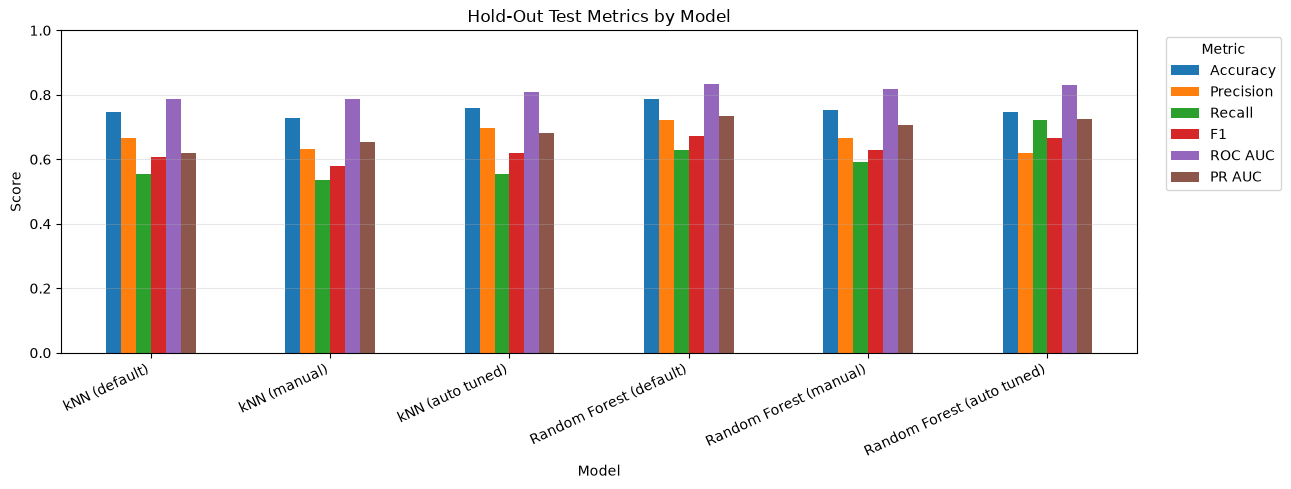

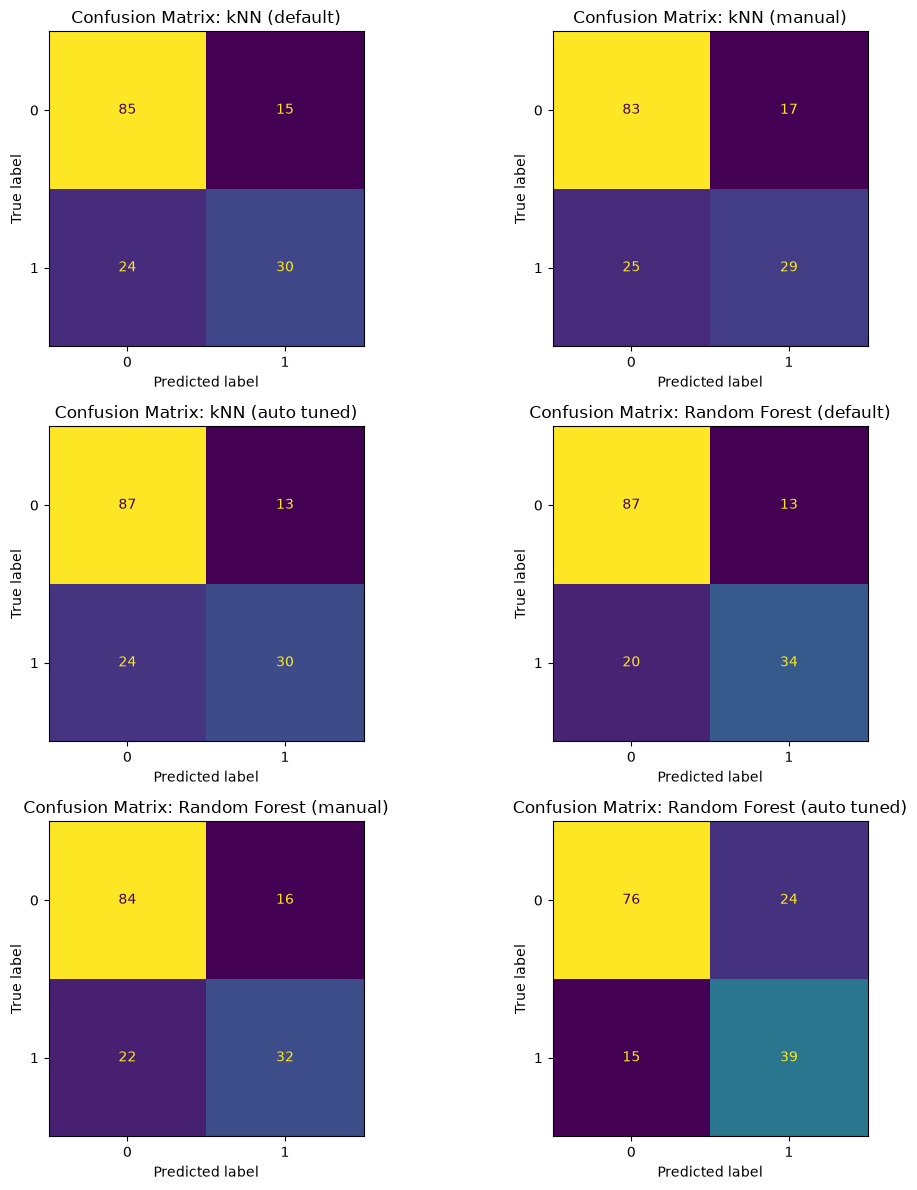

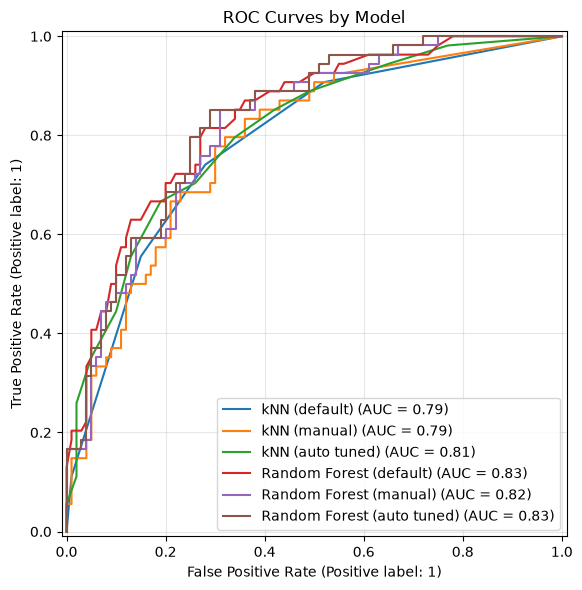

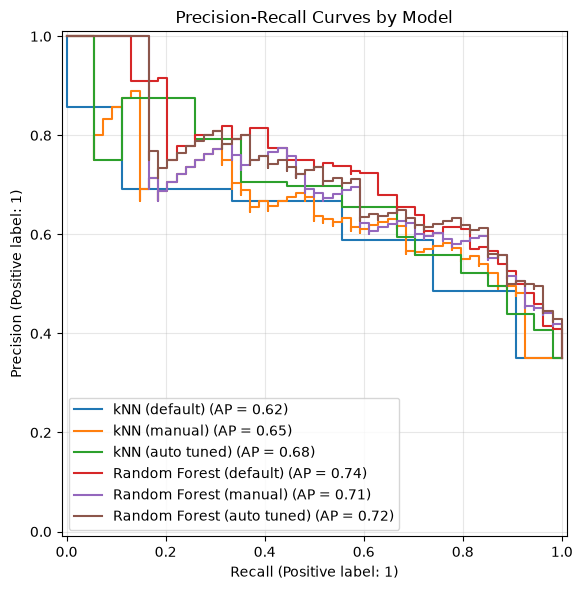

In [181]:
model_order = [
    'kNN (default)',
    'kNN (manual)',
    'kNN (auto tuned)',
    'Random Forest (default)',
    'Random Forest (manual)',
    'Random Forest (auto tuned)',
]
model_order = [m for m in model_order if m in trained_models]

# モデルごとに、学習時と同じ形式のテストデータを使う。
# Pipeline を使う kNN(auto tuned) は X_test、それ以外は auto_X_test を使う。
metric_columns = [
    'test_accuracy',
    'test_precision',
    'test_recall',
    'test_f1',
    'test_roc_auc',
    'test_pr_auc',
]
metric_names = {
    'test_accuracy': 'Accuracy',
    'test_precision': 'Precision',
    'test_recall': 'Recall',
    'test_f1': 'F1',
    'test_roc_auc': 'ROC AUC',
    'test_pr_auc': 'PR AUC',
}
metrics_for_plot = (
    comparison_df.set_index('model')
    .loc[model_order, metric_columns]
    .rename(columns=metric_names)
)

ax = metrics_for_plot.plot(kind='bar', figsize=(13, 5), ylim=(0, 1))
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Hold-Out Test Metrics by Model')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=25, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 混同行列
n_cols = 2
n_rows = (len(model_order) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 4 * n_rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]

for ax, model_name in zip(axes, model_order):
    model = trained_models[model_name]
    test_features = model_test_features.get(model_name, auto_X_test)
    test_predictions = model.predict(test_features)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_predictions,
        labels=[0, 1],
        display_labels=['0', '1'],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f'Confusion Matrix: {model_name}')

for ax in axes[len(model_order):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# ROC 曲線
fig, ax = plt.subplots(figsize=(7, 6))

for model_name in model_order:
    model = trained_models[model_name]
    test_features = model_test_features.get(model_name, auto_X_test)
    RocCurveDisplay.from_estimator(model, test_features, y_test, ax=ax, name=model_name)

ax.set_title('ROC Curves by Model')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PR 曲線
fig, ax = plt.subplots(figsize=(7, 6))

for model_name in model_order:
    model = trained_models[model_name]
    test_features = model_test_features.get(model_name, auto_X_test)
    PrecisionRecallDisplay.from_estimator(
        model, test_features, y_test, ax=ax, name=model_name
    )

ax.set_title('Precision-Recall Curves by Model')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 特徴量重要度の確認

このセルでは、Random Forest の `feature_importances_` と Permutation Importance を使って、どの特徴量が予測に効いているかを確認する。


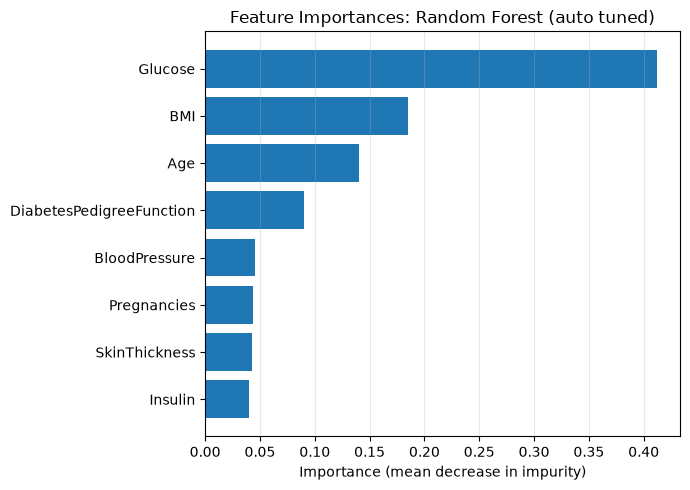

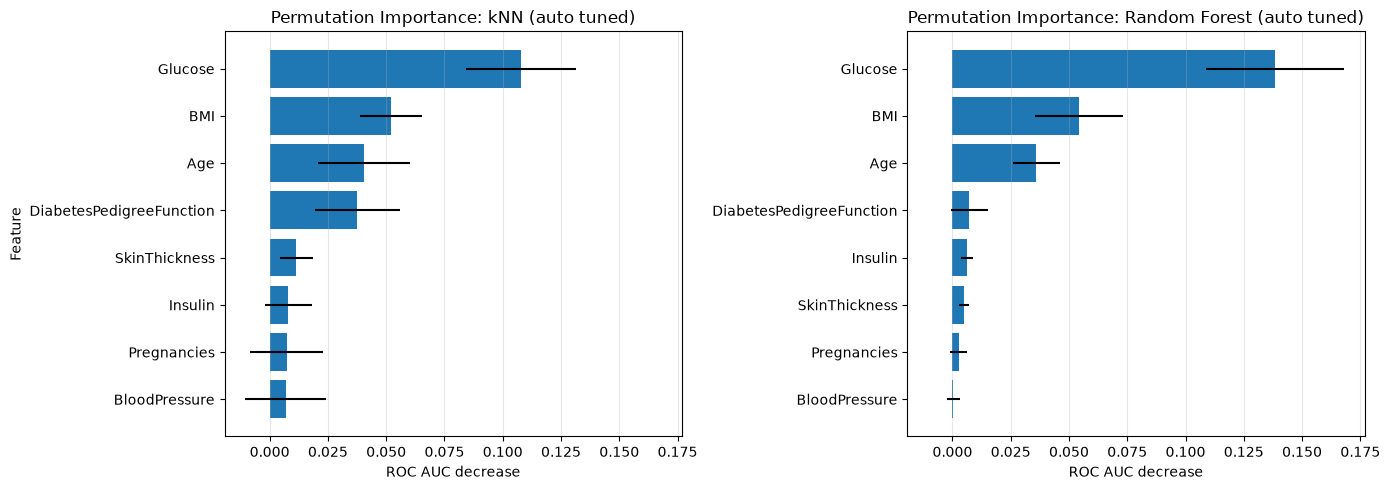

,Model,Feature,Importance,Std
9,Random Forest (auto tuned),Glucose,0.138435,0.029495
13,Random Forest (auto tuned),BMI,0.054343,0.018783
15,Random Forest (auto tuned),Age,0.035954,0.010153
14,Random Forest (auto tuned),DiabetesPedigreeFunction,0.007259,0.007823
12,Random Forest (auto tuned),Insulin,0.006259,0.002463
11,Random Forest (auto tuned),SkinThickness,0.004806,0.002198
8,Random Forest (auto tuned),Pregnancies,0.002694,0.003752
10,Random Forest (auto tuned),BloodPressure,0.000444,0.002686
1,kNN (auto tuned),Glucose,0.107755,0.023608
5,kNN (auto tuned),BMI,0.051954,0.013323


In [182]:
# ① Random Forest の feature_importances_ による特徴量重要度
# feature_importances_ は RF が学習した不純度の減少量に基づく重要度。
# 参照書（金子弘真）に倣い、RF の場合はまずこちらを確認する。
rf_tuned_model = trained_models['Random Forest (auto tuned)']
best_estimator = rf_tuned_model.best_estimator_

rf_importances = pd.DataFrame(
    {'Feature': X_train.columns, 'Importance': best_estimator.feature_importances_}
).sort_values(by='Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(rf_importances['Feature'], rf_importances['Importance'])
ax.set_title('Feature Importances: Random Forest (auto tuned)')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ② Permutation Importance（モデル非依存・kNN と RF の両方で比較）
# 値が大きいほど、その特徴量をシャッフルしたときに ROC AUC が下がりやすいことを表す。
importance_targets = {
    'kNN (auto tuned)': trained_models['kNN (auto tuned)'],
    'Random Forest (auto tuned)': trained_models['Random Forest (auto tuned)'],
}

importance_rows = []

for model_name, model in importance_targets.items():
    result = permutation_importance(
        model,
        model_test_features.get(model_name, auto_X_test),
        y_test,
        scoring='roc_auc',
        n_repeats=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    for feature, imp, std in zip(X_train.columns, result.importances_mean, result.importances_std):
        importance_rows.append({'Model': model_name, 'Feature': feature, 'Importance': imp, 'Std': std})

permutation_importance_df = pd.DataFrame(importance_rows)

fig, axes = plt.subplots(1, len(importance_targets), figsize=(14, 5), sharex=True)
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]

for ax, model_name in zip(axes, importance_targets):
    plot_df = permutation_importance_df[
        permutation_importance_df['Model'] == model_name
    ].sort_values(by='Importance', ascending=True)
    ax.barh(plot_df['Feature'], plot_df['Importance'], xerr=plot_df['Std'])
    ax.set_title(f'Permutation Importance: {model_name}')
    ax.set_xlabel('ROC AUC decrease')
    ax.grid(True, axis='x', alpha=0.3)

axes[0].set_ylabel('Feature')
plt.tight_layout()
plt.show()

permutation_importance_df.sort_values(by=['Model', 'Importance'], ascending=[True, False])


## 最良モデルの予測結果を確認

このセルでは、テストセットの ROC AUC が最も高かったモデルを選び、実際の値、予測クラス、`Outcome=1` の予測確率を表示する。


In [183]:
# 最も ROC AUC が高かったモデルについて、テストデータの予測結果を確認する。
best_row = comparison_df.sort_values(by='test_roc_auc', ascending=False).iloc[0]
best_model_name = best_row['model']
best_model = trained_models[best_model_name]

best_test_features = model_test_features.get(best_model_name, auto_X_test)
best_predictions = best_model.predict(best_test_features)
best_probabilities = best_model.predict_proba(best_test_features)[:, 1]

print(f'テストセットの ROC AUC が最も高かったモデル: {best_model_name}')

prediction_sample = pd.DataFrame(
    {
        'actual_Outcome': y_test,
        'predicted_Outcome': best_predictions,
        'probability_Outcome_1': best_probabilities,
    },
    index=y_test.index,
)

prediction_sample.head(10)

テストセットの ROC AUC が最も高かったモデル: Random Forest (default)


,actual_Outcome,predicted_Outcome,probability_Outcome_1
44,0,1,0.63
672,0,0,0.27
700,0,0,0.06
630,1,0,0.30
81,0,0,0.07
389,0,0,0.35
387,1,1,0.54
408,1,1,0.73
163,0,0,0.02
335,0,1,0.75
